# **UGST4158 — Introduction to Public Policy 2025/26 Winter**
# Central European University
## Time Series Analysis on Air Quality of Turin

Quantitative Methods Seminar
- Liza Drini
- Benedek Szalma
- Zeteny Cseresznyes  

### 0. Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import zscore

### 1. Data Loading

In [2]:
df = pd.read_csv('../Data/turin_air_quality.csv')
df.head()

,time_stamp,sensor_index,humidity,temperature,pressure,pm2.5_atm,pm2.5_atm_a,pm2.5_atm_b,pm10.0_atm
0,1645660800,133001,34.0,56.0,965.51,40.1,41.2,39.1,49.9
1,1645747200,133001,28.0,58.0,964.97,30.9,31.1,30.6,37.7
2,1645833600,133001,14.0,56.0,970.97,1.3,1.2,1.3,1.5
3,1645920000,133001,23.0,53.0,972.36,4.3,4.4,4.3,4.8
4,1646092800,133001,31.0,47.0,974.91,19.3,20.3,18.3,21.8


### 2. Data Preprocessing

#### 2.1. Data Types

In [3]:
df.dtypes

time_stamp        int64
sensor_index      int64
humidity        float64
temperature     float64
pressure        float64
pm2.5_atm       float64
pm2.5_atm_a     float64
pm2.5_atm_b     float64
pm10.0_atm      float64
dtype: object

#### 2.2. Timestamp Conversion

In [4]:
df['time_stamp'] = pd.to_datetime(df['time_stamp'], unit='s')
df['time_stamp'] = df['time_stamp'].dt.strftime('%Y-%m-%d')
df['time_stamp']

0       2022-02-24
1       2022-02-25
2       2022-02-26
3       2022-02-27
4       2022-03-01
           ...    
1352    2025-12-26
1353    2025-12-27
1354    2025-12-28
1355    2025-12-29
1356    2025-12-30
Name: time_stamp, Length: 1357, dtype: str

#### 2.3. Set Index and Sort

In [5]:
df = df.set_index('time_stamp')
df = df.sort_index()

#### 2.4. Missing Values

In [6]:
df.isna().sum()

sensor_index    0
humidity        4
temperature     4
pressure        4
pm2.5_atm       0
pm2.5_atm_a     0
pm2.5_atm_b     0
pm10.0_atm      0
dtype: int64

### 3. Time Series Plots

#### 3.1. PM2.5 and PM10 Over Time

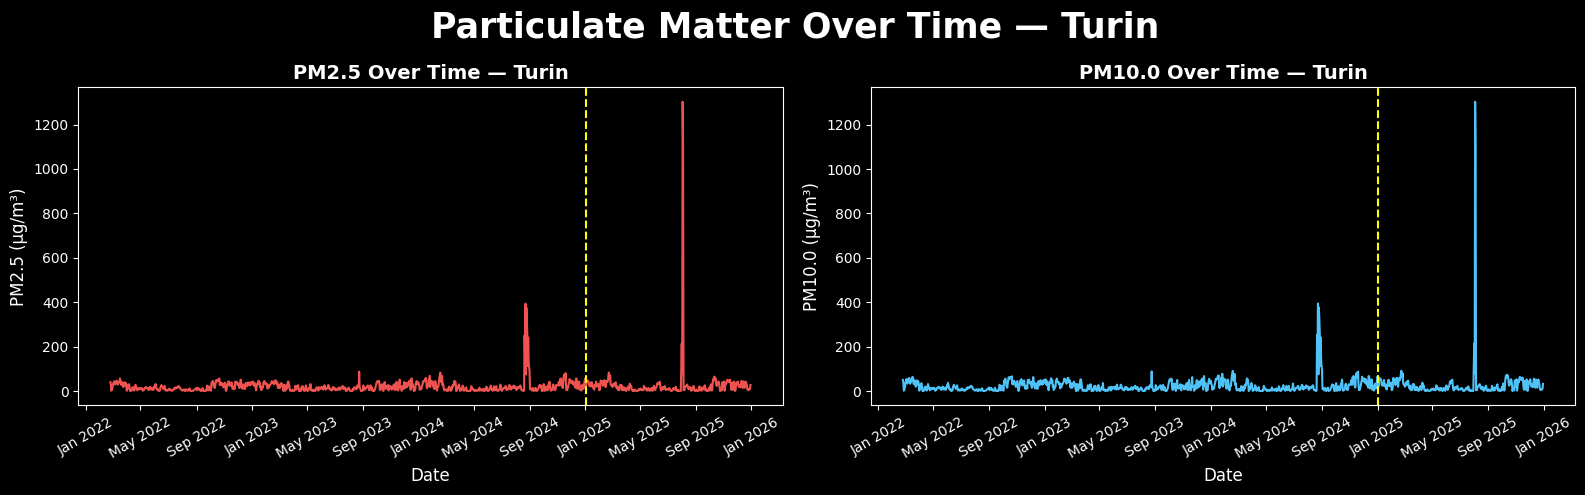

In [7]:
with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(pd.to_datetime(df.index), df['pm2.5_atm'], color='#ef5350', linewidth=1.5)
    axes[0].set_title("PM2.5 Over Time — Turin", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Date", fontsize=12)
    axes[0].set_ylabel("PM2.5 (µg/m³)", fontsize=12)
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[0].tick_params(axis='x', rotation=30, labelsize=10)
    axes[0].tick_params(axis='y', labelsize=10)
    axes[0].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    axes[0].grid(False)

    axes[1].plot(pd.to_datetime(df.index), df['pm10.0_atm'], color='#4fc3f7', linewidth=1.5)
    axes[1].set_title("PM10.0 Over Time — Turin", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Date", fontsize=12)
    axes[1].set_ylabel("PM10.0 (µg/m³)", fontsize=12)
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].tick_params(axis='x', rotation=30, labelsize=10)
    axes[1].tick_params(axis='y', labelsize=10)
    axes[1].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    axes[1].grid(False)

    fig.suptitle("Particulate Matter Over Time — Turin", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/particulate_matter_over_time_turin.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 3.2. PM2.5 and PM10 — 7-Day Rolling Average

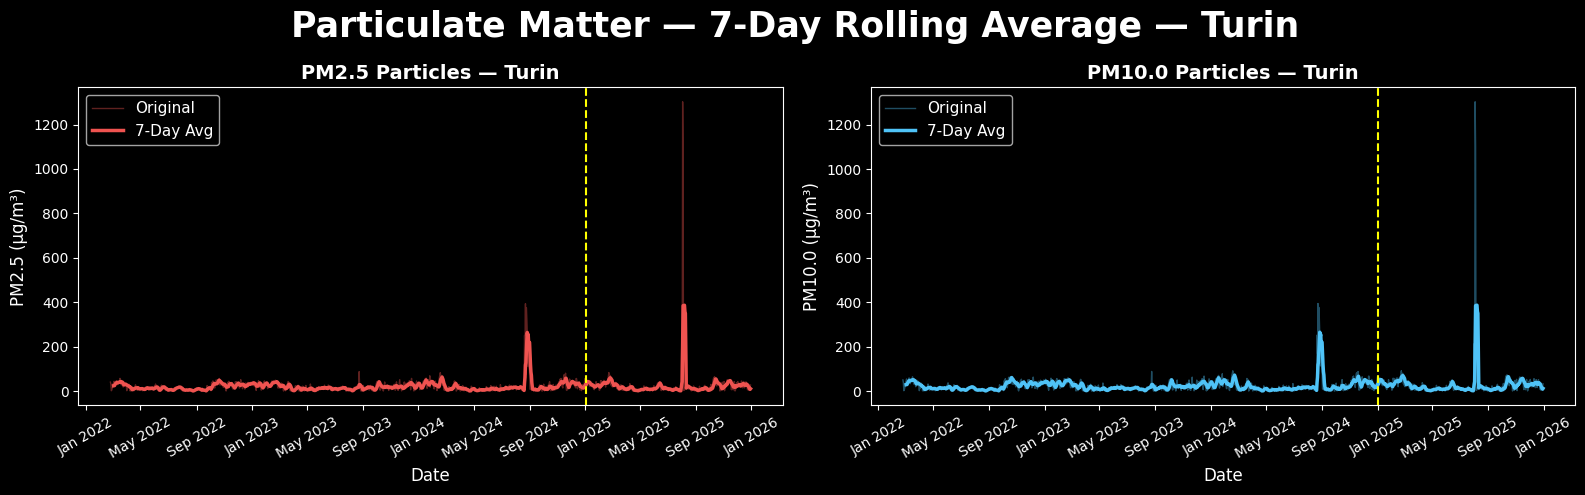

In [8]:
df['pm2.5_7day_avg'] = df['pm2.5_atm'].rolling(window=7).mean()
df['pm10_7day_avg']  = df['pm10.0_atm'].rolling(window=7).mean()

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(pd.to_datetime(df.index), df['pm2.5_atm'], alpha=0.4, color='#ef5350', label='Original', linewidth=1)
    axes[0].plot(pd.to_datetime(df.index), df['pm2.5_7day_avg'], color='#ef5350', label='7-Day Avg', linewidth=2.5)
    axes[0].set_title("PM2.5 Particles — Turin", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Date", fontsize=12)
    axes[0].set_ylabel("PM2.5 (µg/m³)", fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[0].tick_params(axis='x', rotation=30, labelsize=10)
    axes[0].tick_params(axis='y', labelsize=10)
    axes[0].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    axes[0].grid(False)

    axes[1].plot(pd.to_datetime(df.index), df['pm10.0_atm'], alpha=0.4, color='#4fc3f7', label='Original', linewidth=1)
    axes[1].plot(pd.to_datetime(df.index), df['pm10_7day_avg'], color='#4fc3f7', label='7-Day Avg', linewidth=2.5)
    axes[1].set_title("PM10.0 Particles — Turin", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Date", fontsize=12)
    axes[1].set_ylabel("PM10.0 (µg/m³)", fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].tick_params(axis='x', rotation=30, labelsize=10)
    axes[1].tick_params(axis='y', labelsize=10)
    axes[1].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    axes[1].grid(False)

    fig.suptitle("Particulate Matter — 7-Day Rolling Average — Turin", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/particulate_matter_7_day_rolling_average_turin.png', dpi=150, bbox_inches='tight')
    plt.show()

### 4. Outlier Treatment

#### 4.1. Z-Score Anomaly Detection

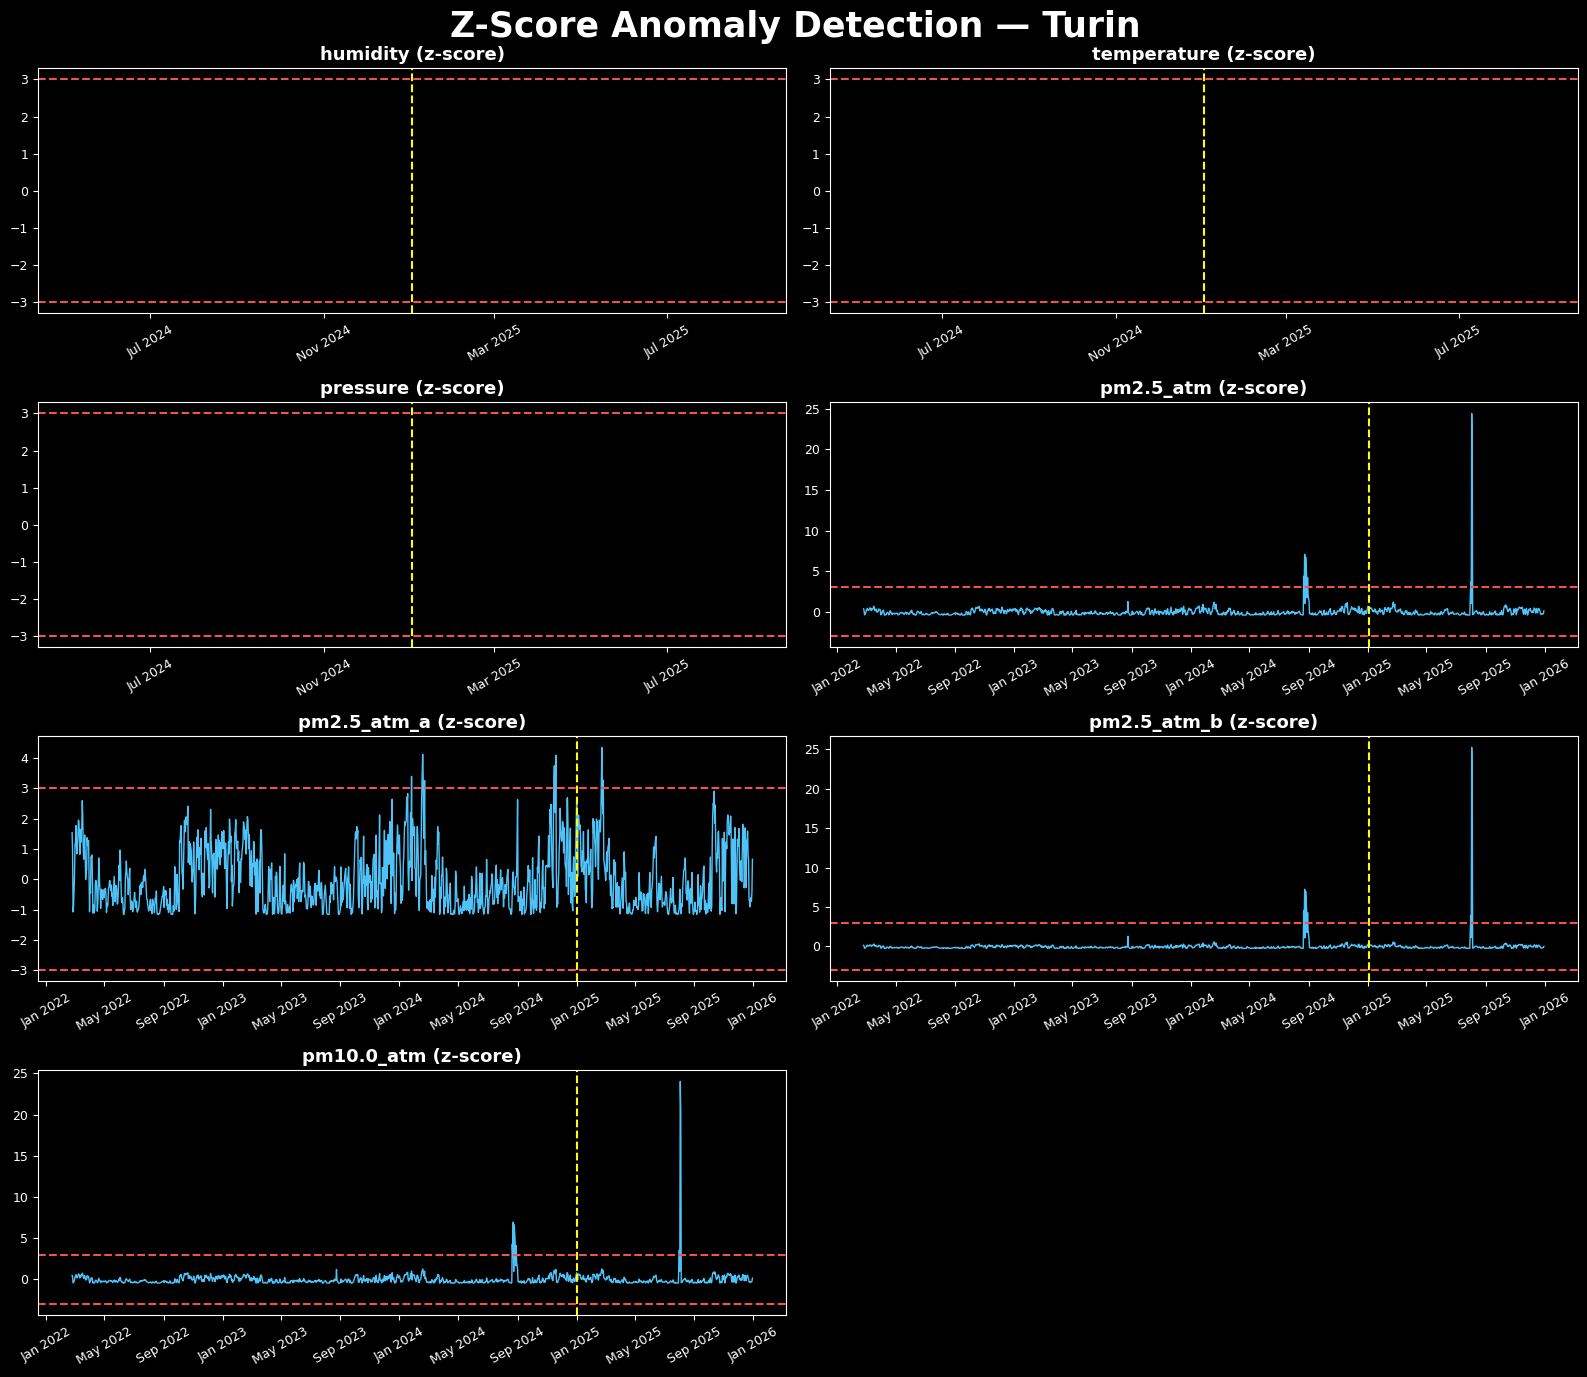

In [9]:
features = [
    'humidity', 'temperature', 'pressure',
    'pm2.5_atm', 'pm2.5_atm_a', 'pm2.5_atm_b',
    'pm10.0_atm'
]

df = df.reset_index()
df_z = df.copy()
df_z[features] = df[features].apply(zscore)

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(4, 2, figsize=(16, 14))
    axes = axes.flatten()

    for ax, col in zip(axes, features):
        ax.plot(pd.to_datetime(df['time_stamp']), df_z[col], color='#4fc3f7', linewidth=1)
        ax.axhline(3,  color='#ef5350', linestyle='--', linewidth=1.5)
        ax.axhline(-3, color='#ef5350', linestyle='--', linewidth=1.5)
        ax.set_title(f'{col} (z-score)', fontsize=13, fontweight='bold')
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=30, labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        ax.axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        ax.grid(False)

    axes[-1].set_visible(False)
    fig.suptitle("Z-Score Anomaly Detection — Turin", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/z_score_anomaly_detection_turin.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 4.2. Clean and Interpolate

outlier counts per feature (rolling median ± 2×MAD, 30-day window):
humidity       188
temperature    223
pressure       270
pm2.5_atm      202
pm2.5_atm_a    196
pm2.5_atm_b    204
pm10.0_atm     207
Name: count, dtype: int64

total outlier values : 1490
rows with ≥1 outlier : 666


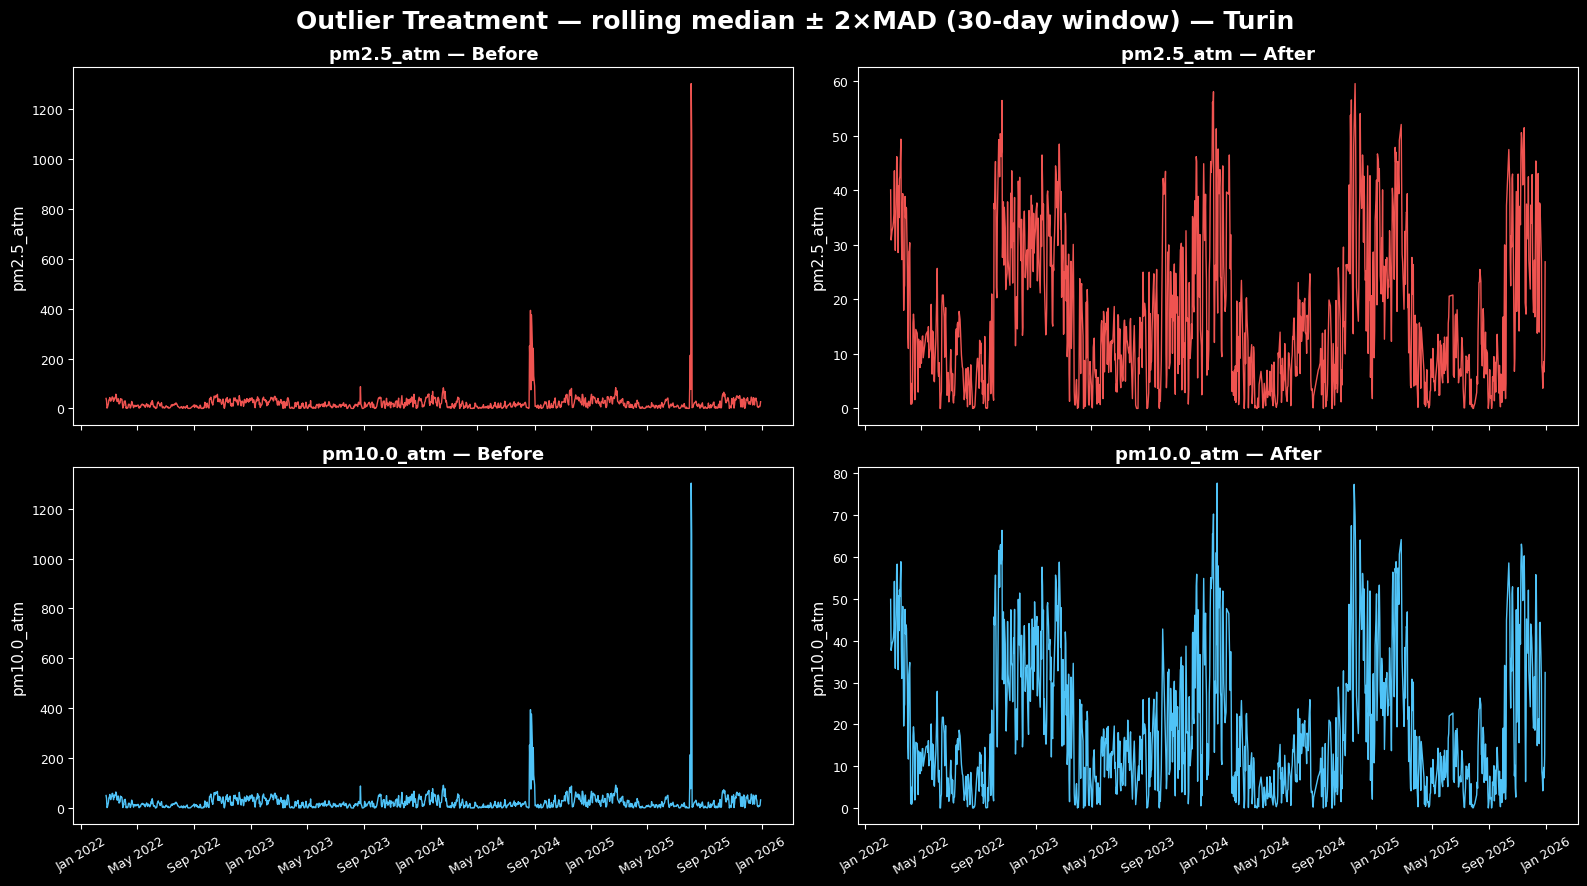

In [10]:

# rolling median ± K × rolling MAD
# median and MAD are both robust to outliers — noise does not inflate the bounds
# center=True uses a symmetric window; min_periods avoids NaN at the edges
WINDOW = 30   # 30-day local reference window
K      = 2.0  # strict multiplier

df_clean = df.copy()
outlier_mask = pd.DataFrame(False, index=df.index, columns=features)

for col in features:
    series   = df[col]
    roll_med = series.rolling(window=WINDOW, center=True, min_periods=7).median()
    roll_mad = (series - roll_med).abs().rolling(window=WINDOW, center=True, min_periods=7).median()
    lo = roll_med - K * roll_mad
    hi = roll_med + K * roll_mad
    outlier_mask[col] = (series < lo) | (series > hi)

print("outlier counts per feature (rolling median ± 2×MAD, 30-day window):")
print(outlier_mask.sum().rename("count"))
print(f"\ntotal outlier values : {outlier_mask.sum().sum()}")
print(f"rows with ≥1 outlier : {outlier_mask.any(axis=1).sum()}")

# replace with NaN, then linearly interpolate
for col in features:
    df_clean.loc[outlier_mask[col], col] = np.nan
df_clean[features] = df_clean[features].interpolate(method='linear')

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)

    for row, (col, color) in enumerate(zip(['pm2.5_atm', 'pm10.0_atm'], ['#ef5350', '#4fc3f7'])):
        axes[row, 0].plot(pd.to_datetime(df['time_stamp']), df[col], color=color, linewidth=1)
        axes[row, 0].set_title(f'{col} — Before', fontsize=13, fontweight='bold')
        axes[row, 0].set_ylabel(col, fontsize=11)
        axes[row, 0].tick_params(axis='y', labelsize=9)
        axes[row, 0].grid(False)

        axes[row, 1].plot(pd.to_datetime(df_clean['time_stamp']), df_clean[col], color=color, linewidth=1)
        axes[row, 1].set_title(f'{col} — After', fontsize=13, fontweight='bold')
        axes[row, 1].set_ylabel(col, fontsize=11)
        axes[row, 1].tick_params(axis='y', labelsize=9)
        axes[row, 1].grid(False)

    axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    for ax in axes[-1]:
        ax.tick_params(axis='x', rotation=30, labelsize=9)

    fig.suptitle("Outlier Treatment — rolling median ± 2×MAD (30-day window) — Turin",
                 fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Figures/outlier_treatment_rolling_median_2_mad_30_day_window_turin.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series Analysis

#### 5.1. Set Frequency

In [11]:
df_ts = df_clean.copy()
df_ts['time_stamp'] = pd.to_datetime(df_ts['time_stamp'])
df_ts = df_ts.set_index('time_stamp')[features]
df_ts = df_ts.asfreq('D')

#### 5.2. PM2.5 Overview

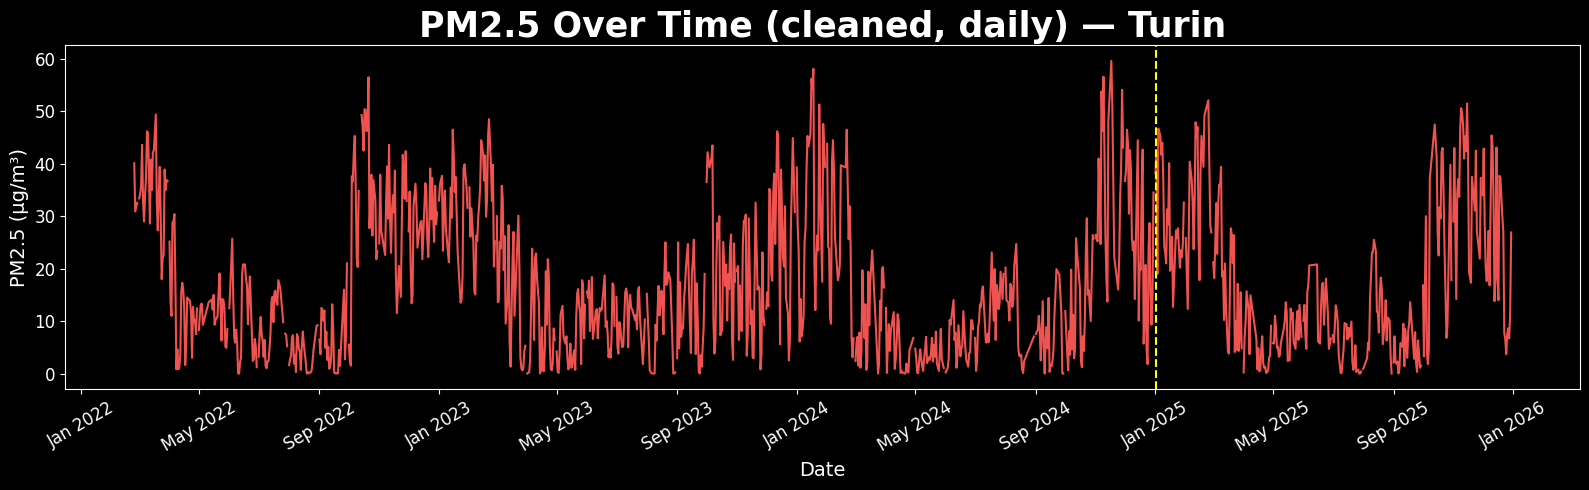

In [12]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df_ts.index, df_ts['pm2.5_atm'], color='#ef5350', linewidth=1.5)
    ax.set_title('PM2.5 Over Time (cleaned, daily) — Turin', fontsize=25, fontweight="bold")
    ax.set_xlabel("Date", fontsize=14)
    ax.set_ylabel("PM2.5 (µg/m³)", fontsize=14)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig('../Figures/pm2_5_over_time_cleaned_daily_turin.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 5.3. Stationarity Test (ADF)

In [13]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_ts['pm2.5_atm'].dropna())
print("PM2.5 ADF p-value:", result[1])
result = adfuller(df_ts['pm10.0_atm'].dropna())
print("PM10 ADF p-value:", result[1])

PM2.5 ADF p-value: 0.00015945383991761494
PM10 ADF p-value: 0.0002632496944383787


#### 5.4. Seasonal Decomposition — PM2.5 and PM10

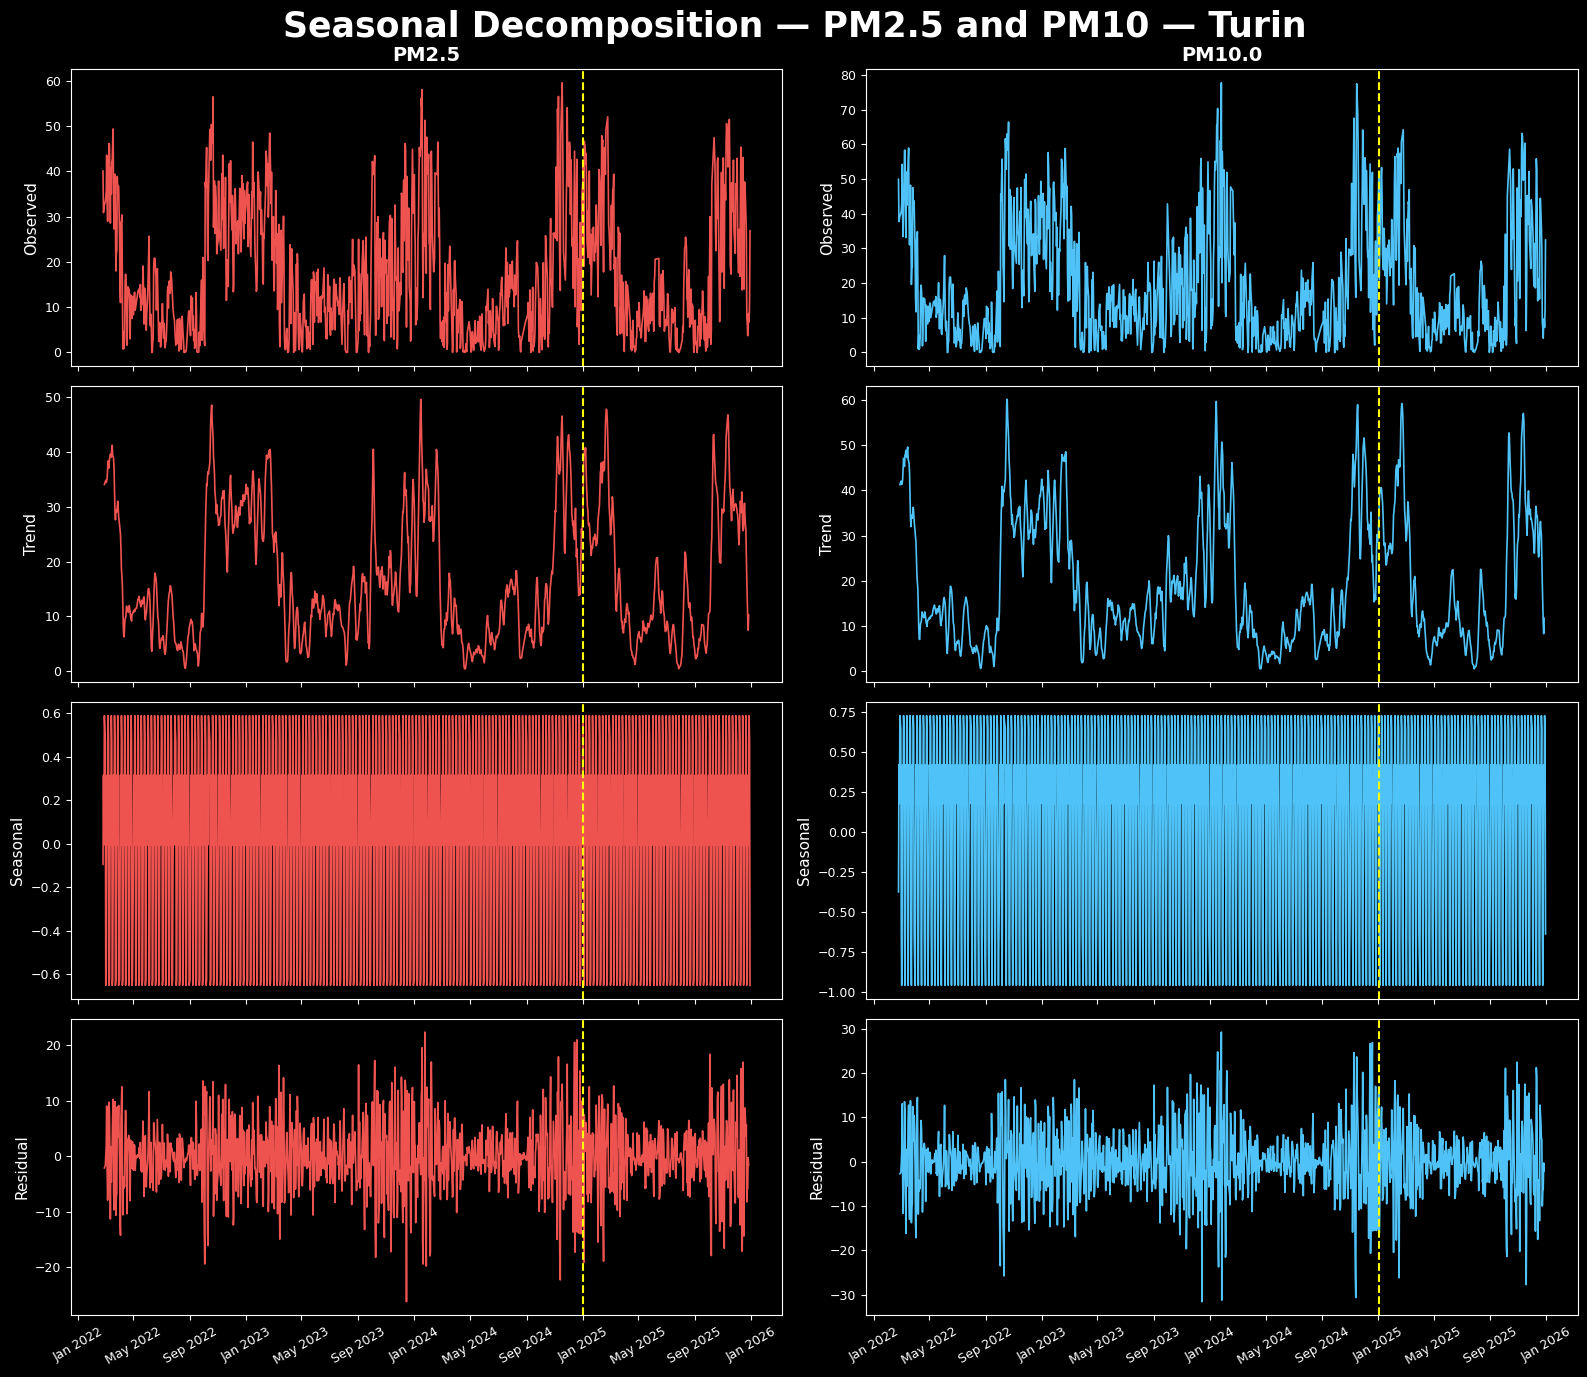

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

result  = seasonal_decompose(df_ts['pm2.5_atm'].dropna(),  model='additive', period=7)
result2 = seasonal_decompose(df_ts['pm10.0_atm'].dropna(), model='additive', period=7)

components = [
    (result.observed, result2.observed, 'Observed'),
    (result.trend,    result2.trend,    'Trend'),
    (result.seasonal, result2.seasonal, 'Seasonal'),
    (result.resid,    result2.resid,    'Residual'),
]

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)

    for i, (pm25_comp, pm10_comp, label) in enumerate(components):
        axes[i, 0].plot(pd.to_datetime(pm25_comp.index), pm25_comp, color='#ef5350', linewidth=1.2)
        axes[i, 0].set_ylabel(label, fontsize=11)
        axes[i, 0].tick_params(axis='y', labelsize=9)
        axes[i, 0].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        axes[i, 0].grid(False)

        axes[i, 1].plot(pd.to_datetime(pm10_comp.index), pm10_comp, color='#4fc3f7', linewidth=1.2)
        axes[i, 1].set_ylabel(label, fontsize=11)
        axes[i, 1].tick_params(axis='y', labelsize=9)
        axes[i, 1].axvline(pd.Timestamp('2025-01-02'), color='yellow', linestyle='--', linewidth=1.5)
        axes[i, 1].grid(False)

    axes[0, 0].set_title("PM2.5", fontsize=14, fontweight="bold")
    axes[0, 1].set_title("PM10.0", fontsize=14, fontweight="bold")

    axes[-1, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    for ax in axes[-1]:
        ax.tick_params(axis='x', rotation=30, labelsize=9)

    fig.suptitle("Seasonal Decomposition — PM2.5 and PM10 — Turin", fontsize=25, fontweight="bold")
    plt.tight_layout()
    plt.savefig('../Figures/seasonal_decomposition_pm2_5_and_pm10_turin.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 5.5. Correlation with Environmental Factors — PM2.5

In [15]:
df_ts[['pm2.5_atm', 'temperature', 'humidity']].corr()

,pm2.5_atm,temperature,humidity
pm2.5_atm,1.000000,-0.514370,0.222395
temperature,-0.514370,1.000000,-0.281197
humidity,0.222395,-0.281197,1.000000


#### 5.6. Correlation with Environmental Factors — PM10

In [16]:
df_ts[['pm10.0_atm', 'temperature', 'humidity']].corr()

,pm10.0_atm,temperature,humidity
pm10.0_atm,1.000000,-0.521253,0.215928
temperature,-0.521253,1.000000,-0.281197
humidity,0.215928,-0.281197,1.000000


### 6. Time Series Forecasting (SARIMAX)

#### 6.1. PM2.5 SARIMAX Forecast

c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_ind

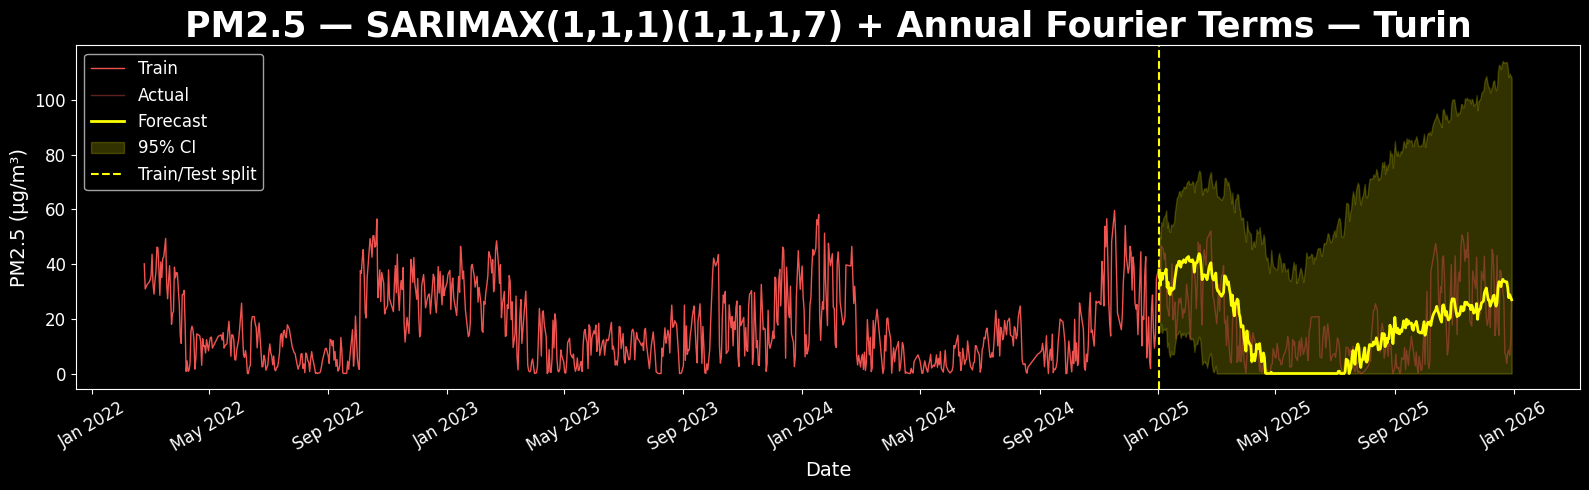

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

SPLIT = pd.Timestamp('2025-01-02')

def fourier_terms(index, period=365.25, K=3):
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

fourier   = fourier_terms(df_ts.index)
exog_cols = ['temperature', 'humidity']

pm25_series = df_ts['pm2.5_atm'].dropna()
exog_all    = df_ts[exog_cols].join(fourier).reindex(pm25_series.index).interpolate()

pm25_train = pm25_series[pm25_series.index < SPLIT]
pm25_test  = pm25_series[pm25_series.index >= SPLIT]
exog_train = exog_all[exog_all.index < SPLIT]
exog_test  = exog_all[exog_all.index >= SPLIT]

model_fit_pm25 = SARIMAX(
    pm25_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
).fit(disp=False)

fc      = model_fit_pm25.get_forecast(steps=len(pm25_test), exog=exog_test)
fc_mean = fc.predicted_mean.clip(lower=0)   # pm2.5 cannot be negative
fc_ci   = fc.conf_int().clip(lower=0)
fc_mean.index = pm25_test.index
fc_ci.index   = pm25_test.index

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.plot(pm25_train.index, pm25_train, color='#ef5350', linewidth=1,            label='Train')
    ax.plot(pm25_test.index,  pm25_test,  color='#ef5350', linewidth=1, alpha=0.4, label='Actual')
    ax.plot(fc_mean.index,    fc_mean,    color='yellow',  linewidth=2,            label='Forecast')
    ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                    color='yellow', alpha=0.2, label='95% CI')
    ax.axvline(SPLIT, color='yellow', linestyle='--', linewidth=1.5, label='Train/Test split')

    ax.set_title('PM2.5 — SARIMAX(1,1,1)(1,1,1,7) + Annual Fourier Terms — Turin', fontsize=25, fontweight='bold')
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=14)
    ax.legend(fontsize=12)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig('../Figures/pm2_5_sarimax_1_1_1_1_1_1_7_annual_fourier_terms_turin.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 6.2. PM10 SARIMAX Forecast

c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_ind

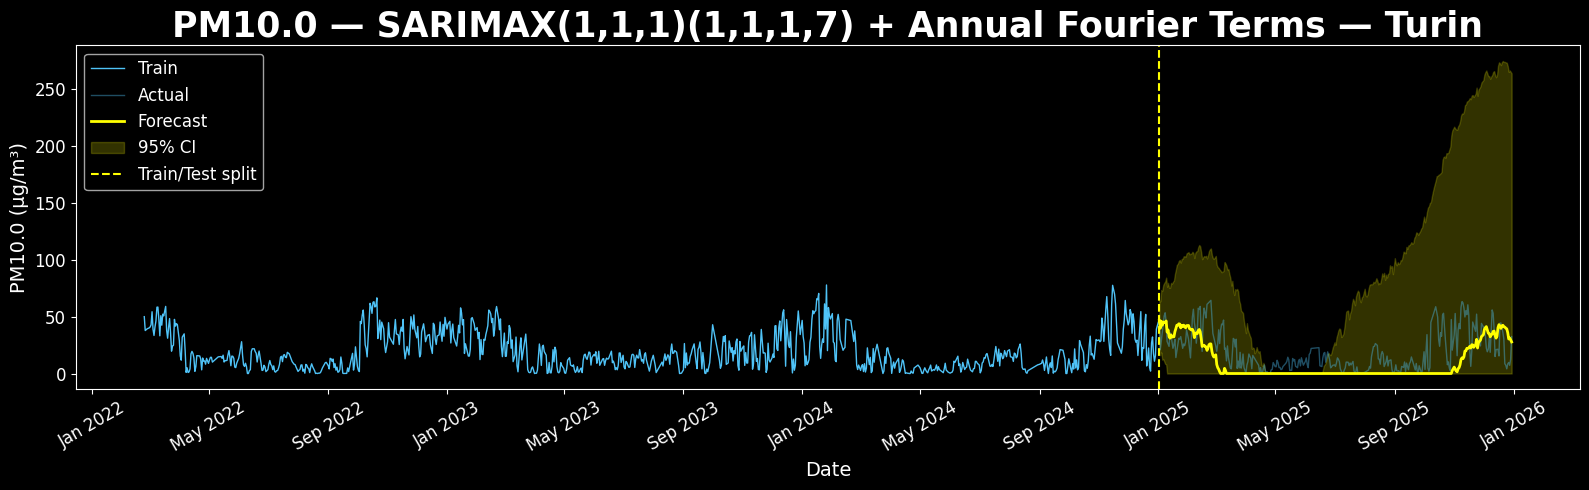

In [18]:
pm10_series = df_ts['pm10.0_atm'].dropna()
exog_all    = df_ts[exog_cols].join(fourier).reindex(pm10_series.index).interpolate()

pm10_train = pm10_series[pm10_series.index < SPLIT]
pm10_test  = pm10_series[pm10_series.index >= SPLIT]
exog_train = exog_all[exog_all.index < SPLIT]
exog_test  = exog_all[exog_all.index >= SPLIT]

model_fit_pm10 = SARIMAX(
    pm10_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
).fit(disp=False)

fc      = model_fit_pm10.get_forecast(steps=len(pm10_test), exog=exog_test)
fc_mean = fc.predicted_mean.clip(lower=0)   # pm10 cannot be negative
fc_ci   = fc.conf_int().clip(lower=0)
fc_mean.index = pm10_test.index
fc_ci.index   = pm10_test.index

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.plot(pm10_train.index, pm10_train, color='#4fc3f7', linewidth=1,            label='Train')
    ax.plot(pm10_test.index,  pm10_test,  color='#4fc3f7', linewidth=1, alpha=0.4, label='Actual')
    ax.plot(fc_mean.index,    fc_mean,    color='yellow',  linewidth=2,            label='Forecast')
    ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                    color='yellow', alpha=0.2, label='95% CI')
    ax.axvline(SPLIT, color='yellow', linestyle='--', linewidth=1.5, label='Train/Test split')

    ax.set_title('PM10.0 — SARIMAX(1,1,1)(1,1,1,7) + Annual Fourier Terms — Turin', fontsize=25, fontweight='bold')
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('PM10.0 (µg/m³)', fontsize=14)
    ax.legend(fontsize=12)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig('../Figures/pm10_0_sarimax_1_1_1_1_1_1_7_annual_fourier_terms_turin.png', dpi=150, bbox_inches='tight')
    plt.show()